# Experiment Summary

Tidy summary of all 16 experiment runs (4 models x 4 losses), aggregated per image,
per model, and per loss. Source data: `outputs/experiments/run_*/results/*/cross_validation_results.csv`.


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

ROOT = Path.cwd()
if not (ROOT / "outputs" / "experiments").exists():
    ROOT = ROOT.parent
EXP_DIR = ROOT / "outputs" / "experiments"

MODEL_ORDER = ["UNet", "UNetPP", "ResUNet", "AF_BMAU_Net"]
MODEL_DISPLAY = {"UNet": "U-Net", "UNetPP": "U-Net++", "ResUNet": "ResUNet", "AF_BMAU_Net": "AF-BMAU-Net"}
LOSS_ORDER = ["dice", "focal", "boundary", "hybrid"]
LOSS_DISPLAY = {"dice": "Dice", "focal": "Focal", "boundary": "Boundary", "hybrid": "Hybrid"}
METRICS = ["dice", "iou", "precision", "sensitivity", "specificity", "hd95"]

## Load all runs into one tidy DataFrame

In [2]:
RUN_RE = re.compile(r"run_(af_bmau_net|resunet|unet|unetpp)_(dice|focal|boundary|hybrid)_\d{8}_\d{6}_\w+")
MODEL_KEY_MAP = {"af_bmau_net": "AF_BMAU_Net", "resunet": "ResUNet", "unet": "UNet", "unetpp": "UNetPP"}

runs = []
for d in sorted(EXP_DIR.iterdir()):
    m = RUN_RE.match(d.name)
    if not m:
        continue
    model_slug, loss = m.groups()
    runs.append((d, MODEL_KEY_MAP[model_slug], loss))

frames = []
for d, model, loss in runs:
    df = pd.read_csv(d / "results" / model / "cross_validation_results.csv")
    df["loss"] = loss
    frames.append(df)

df_results = pd.concat(frames, ignore_index=True)
df_results["model"] = pd.Categorical(df_results["model"], categories=MODEL_ORDER, ordered=True)
df_results["loss"] = pd.Categorical(df_results["loss"], categories=LOSS_ORDER, ordered=True)
df_results = df_results[["filename", "model", "loss", "fold"] + METRICS +
                         [c for c in df_results.columns if c not in ["filename", "model", "loss", "fold"] + METRICS]]

print(f"{len(runs)} runs loaded -> df_results: {df_results.shape}")
df_results.head()

16 runs loaded -> df_results: (11520, 17)


,filename,model,loss,fold,dice,iou,precision,sensitivity,specificity,hd95,model_name,pred_dvp_px,pred_dvp_x,pred_dvp_y_top,pred_dvp_y_bottom,dvp_image_width,dvp_image_height
0,CEO003.jpg,AF_BMAU_Net,boundary,1,0.3828,0.2367,0.2367,1.0000,0.0782,119.6131,AF-BMAU-Net,300,0.0000,0.0000,299.0000,400,300
1,CEO007.jpg,AF_BMAU_Net,boundary,1,0.3828,0.2367,0.2367,1.0000,0.0780,119.6280,AF-BMAU-Net,300,0.0000,0.0000,299.0000,400,300
2,CEO011.jpg,AF_BMAU_Net,boundary,1,0.3849,0.2383,0.2383,1.0000,0.0839,127.0031,AF-BMAU-Net,300,0.0000,0.0000,299.0000,400,300
3,CEO031.jpg,AF_BMAU_Net,boundary,1,0.1189,0.0632,0.0632,1.0000,0.0000,138.5686,AF-BMAU-Net,300,0.0000,0.0000,299.0000,400,300
4,CEO032.jpg,AF_BMAU_Net,boundary,1,0.1190,0.0632,0.0632,1.0000,0.0000,137.8278,AF-BMAU-Net,300,0.0000,0.0000,299.0000,400,300


## Per-image summary (long format)

One row per image x model x loss, averaged across the 5 CV folds. This is the
tidy table to filter/groupby/export from — every other view below is derived from it.

In [3]:
per_image = (
    df_results
    .groupby(["filename", "model", "loss"], observed=True)[METRICS]
    .mean()
    .reset_index()
    .sort_values(["filename", "model", "loss"])
)
print(f"per_image: {per_image.shape}  (720 images x 4 models x 4 losses)")
per_image.head(10)

per_image: (11520, 9)  (720 images x 4 models x 4 losses)


,filename,model,loss,dice,iou,precision,sensitivity,specificity,hd95
0,CEO001.jpg,UNet,dice,0.9752,0.9516,0.9645,0.9861,0.9896,3.0000
1,CEO001.jpg,UNet,focal,0.9798,0.9603,0.9934,0.9665,0.9982,2.8284
2,CEO001.jpg,UNet,boundary,0.3638,0.2223,0.2223,1.0000,0.0000,122.1352
3,CEO001.jpg,UNet,hybrid,0.9872,0.9747,0.9853,0.9891,0.9958,1.4142
4,CEO001.jpg,UNetPP,dice,0.9847,0.9699,0.9811,0.9884,0.9945,2.0000
5,CEO001.jpg,UNetPP,focal,0.9861,0.9725,0.9946,0.9777,0.9985,2.0000
6,CEO001.jpg,UNetPP,boundary,0.3645,0.2229,0.2229,1.0000,0.0030,122.0901
7,CEO001.jpg,UNetPP,hybrid,0.9861,0.9725,0.9816,0.9905,0.9947,2.0000
8,CEO001.jpg,ResUNet,dice,0.9736,0.9486,0.9738,0.9734,0.9925,4.0369
9,CEO001.jpg,ResUNet,focal,0.9880,0.9764,0.9948,0.9814,0.9985,1.4142


## Per-image pivot (wide format, for eyeballing)

Rows = image filename, columns = (model, loss), values = Dice. Wide pivots are
derived on demand from `per_image` — handy to scan, not to compute from.

In [4]:
dice_pivot = per_image.pivot(index="filename", columns=["model", "loss"], values="dice")
dice_pivot = dice_pivot.reindex(columns=pd.MultiIndex.from_product([MODEL_ORDER, LOSS_ORDER]))
dice_pivot.head(10)

UNet                        UNetPP                         \
             dice  focal boundary hybrid   dice  focal boundary hybrid   
filename                                                                 
CEO001.jpg 0.9752 0.9798   0.3638 0.9872 0.9847 0.9861   0.3645 0.9861   
CEO002.jpg 0.9849 0.9864   0.2893 0.9888 0.9884 0.9854   0.3639 0.9919   
CEO003.jpg 0.9730 0.9828   0.4247 0.9874 0.9831 0.9862   0.0000 0.9873   
CEO004.jpg 0.9721 0.9770   0.3642 0.9842 0.9811 0.9830   0.3642 0.9851   
CEO005.jpg 0.9832 0.9844   0.2742 0.9887 0.9862 0.9804   0.3643 0.9897   
CEO006.jpg 0.9796 0.9821   0.3639 0.9884 0.9875 0.9878   0.3701 0.9880   
CEO007.jpg 0.9731 0.9828   0.4247 0.9874 0.9829 0.9862   0.0000 0.9873   
CEO008.jpg 0.9875 0.9840   0.0000 0.9897 0.9785 0.9868   0.3639 0.9917   
CEO009.jpg 0.9847 0.9823   0.0182 0.9886 0.9868 0.9873   0.3643 0.9899   
CEO010.jpg 0.9848 0.9835   0.0000 0.9887 0.9774 0.9864   0.3639 0.9910   

           ResUNet                        AF_BMAU_Net                         
              dice  focal boundary hybrid        dice  focal boundary hybrid  
filename                                                                      
CEO001.jpg  0.9736 0.9880   0.3639 0.9829      0.9859 0.9875   0.0000 0.9860  
CEO002.jpg  0.9811 0.9880   0.3639 0.9850      0.9864 0.9894   0.3745 0.9870  
CEO003.jpg  0.9805 0.9883   0.3840 0.9862      0.9836 0.9871   0.3828 0.9862  
CEO004.jpg  0.9677 0.9839   0.3642 0.9801      0.9816 0.9810   0.0000 0.9806  
CEO005.jpg  0.9776 0.9865   0.3643 0.9855      0.9871 0.9886   0.3752 0.9862  
CEO006.jpg  0.9793 0.9883   0.3656 0.9860      0.9879 0.9884   0.0000 0.9903  
CEO007.jpg  0.9805 0.9883   0.3839 0.9862      0.9836 0.9871   0.3828 0.9862  
CEO008.jpg  0.9810 0.9870   0.3982 0.9847      0.9862 0.9880   0.3665 0.9869  
CEO009.jpg  0.9856 0.9879   0.3643 0.9857      0.9870 0.9891   0.0000 0.9881  
CEO010.jpg  0.9802 0.9859   0.3981 0.9874      0.9856 0.9861   0.3673 0.9871

## Model x loss aggregate (mean +/- std across all images/folds)

In [5]:
agg = df_results.groupby(["model", "loss"], observed=True)[METRICS].agg(["mean", "std"])
agg = agg.reindex(MODEL_ORDER, level="model").reindex(LOSS_ORDER, level="loss")

flat = agg.copy()
flat.columns = [f"{metric}_{stat}" for metric, stat in flat.columns]
means = [c for c in flat.columns if c.endswith("_mean")]
flat.style.background_gradient(subset=means, cmap="RdYlGn", axis=0).format("{:.4f}")

## Best (model, loss) per image

For each image, which (model, loss) combination scored the highest Dice?
Useful for spotting images that are hard for every model, or where one
architecture consistently wins.

In [6]:
best_per_image = (
    per_image.loc[per_image.groupby("filename")["dice"].idxmax()]
    .set_index("filename")[["model", "loss", "dice"]]
    .sort_values("dice")
)
print("Hardest images (lowest best-achievable Dice):")
best_per_image.head(10)

Hardest images (lowest best-achievable Dice):


,model,loss,dice
filename,,,
CEO399.jpg,AF_BMAU_Net,dice,0.8353
CEO564.jpg,UNetPP,hybrid,0.8760
CEO392.jpg,UNet,dice,0.9354
CEO132.jpg,ResUNet,dice,0.9392
CEO394.jpg,UNetPP,hybrid,0.9401
CEO565.jpg,UNet,hybrid,0.9477
CEO395.jpg,UNet,dice,0.9484
CEO567.jpg,UNetPP,hybrid,0.9486
CEO383.jpg,UNet,hybrid,0.9487


## Export

In [7]:
OUT_DIR = ROOT / "outputs"
per_image.to_csv(OUT_DIR / "summary_per_image.csv", index=False)
flat.to_csv(OUT_DIR / "summary_model_loss.csv")
print(f"Wrote {OUT_DIR / 'summary_per_image.csv'}")
print(f"Wrote {OUT_DIR / 'summary_model_loss.csv'}")

Wrote d:\ITB STIKOM BALI\PENELITIAN\PENELITIAN DIKTI\DRTPM 2026\dikti-2026-angga-segmentation\outputs\summary_per_image.csv
Wrote d:\ITB STIKOM BALI\PENELITIAN\PENELITIAN DIKTI\DRTPM 2026\dikti-2026-angga-segmentation\outputs\summary_model_loss.csv


## Comparison plot: model x loss grid for one image

`comparison_plot(filename)` renders an *m x n* grid (rows = models, cols =
losses) of that image's prediction overlay for every (model, loss) combo,
reusing the overlay PNGs already produced by training
(`outputs/experiments/<run>/overlays/<model>/fold_<k>/<stem>_overlay.png`,
each annotated with Dice/IoU). Every image sits in exactly one CV fold, and
that fold assignment is identical across all 16 runs, so a single fold lookup
per filename is enough to locate every panel.

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

RUN_DIR = {(model, loss): d for d, model, loss in runs}
FOLD_OF = df_results.drop_duplicates("filename").set_index("filename")["fold"].astype(int).to_dict()

CELL_W, CELL_H = 3.6, 2.7  # matches the 400x300 overlay aspect ratio -> no letterboxing
DPI = 300


def comparison_plot(filename, models=MODEL_ORDER, losses=LOSS_ORDER, figsize=None, dpi=DPI, save_path=None):
    """Plot an m (models) x n (losses) grid of prediction overlays for one image."""
    fold = FOLD_OF[filename]
    stem = Path(filename).stem
    n_rows, n_cols = len(models), len(losses)
    figsize = figsize or (CELL_W * n_cols, CELL_H * n_rows)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, dpi=dpi, squeeze=False)
    fig.subplots_adjust(left=0.035, right=0.995, top=0.90, bottom=0.005, wspace=0.02, hspace=0.03)

    for i, model in enumerate(models):
        for j, loss in enumerate(losses):
            ax = axes[i][j]
            run_dir = RUN_DIR.get((model, loss))
            overlay_path = run_dir / "overlays" / model / f"fold_{fold}" / f"{stem}_overlay.png" if run_dir else None
            if overlay_path and overlay_path.exists():
                ax.imshow(mpimg.imread(overlay_path))
            else:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            if i == 0:
                ax.set_title(LOSS_DISPLAY[loss], fontsize=12, pad=4)
            if j == 0:
                ax.set_ylabel(MODEL_DISPLAY[model], fontsize=12)

    fig.suptitle(f"{filename}  (fold {fold})", fontsize=14, y=0.985)

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    return fig

### Cherry-picked example: AF-BMAU-Net + Hybrid winning big

Selected as the image where AF-BMAU-Net+Hybrid's Dice not only leads but beats
the *single best* of the other 15 (model, loss) combinations by the widest
margin among images where AF-BMAU-Net+Hybrid itself scores > 0.97 — i.e. it
outright wins, not just on average.

In [9]:
target_mask = (per_image["model"] == "AF_BMAU_Net") & (per_image["loss"] == "hybrid")
target = per_image[target_mask][["filename", "dice"]].rename(columns={"dice": "af_hybrid_dice"})

others = per_image[~target_mask & (per_image["loss"] != "boundary")]
other_max = others.groupby("filename")["dice"].max().rename("others_max_dice")

gap = target.merge(other_max, on="filename").set_index("filename")
gap["gap_vs_best_other"] = gap["af_hybrid_dice"] - gap["others_max_dice"]
gap[gap["af_hybrid_dice"] > 0.97].sort_values("gap_vs_best_other", ascending=False).head(10).round(4)

,af_hybrid_dice,others_max_dice,gap_vs_best_other
filename,,,
CEO193.jpg,0.9782,0.9734,0.0048
CEO670.jpg,0.9885,0.9846,0.0039
CEO370.jpg,0.9885,0.9848,0.0037
CEO239.jpg,0.9866,0.9838,0.0028
CEO176.jpg,0.9855,0.9827,0.0028
CEO666.jpg,0.9871,0.9843,0.0028
CEO142.jpg,0.9772,0.9745,0.0027
CEO328.jpg,0.9909,0.9883,0.0027
CEO221.jpg,0.9879,0.9853,0.0026


In [10]:
cherry_picked = "CEO193.jpg"
dice_pivot.loc[cherry_picked].unstack(0).reindex(index=LOSS_ORDER, columns=MODEL_ORDER).round(4)

,UNet,UNetPP,ResUNet,AF_BMAU_Net
dice,0.9602,0.9679,0.9667,0.9734
focal,0.9414,0.9558,0.9672,0.9652
boundary,0.0681,0.0000,0.0679,0.0679
hybrid,0.9698,0.9682,0.9701,0.9782


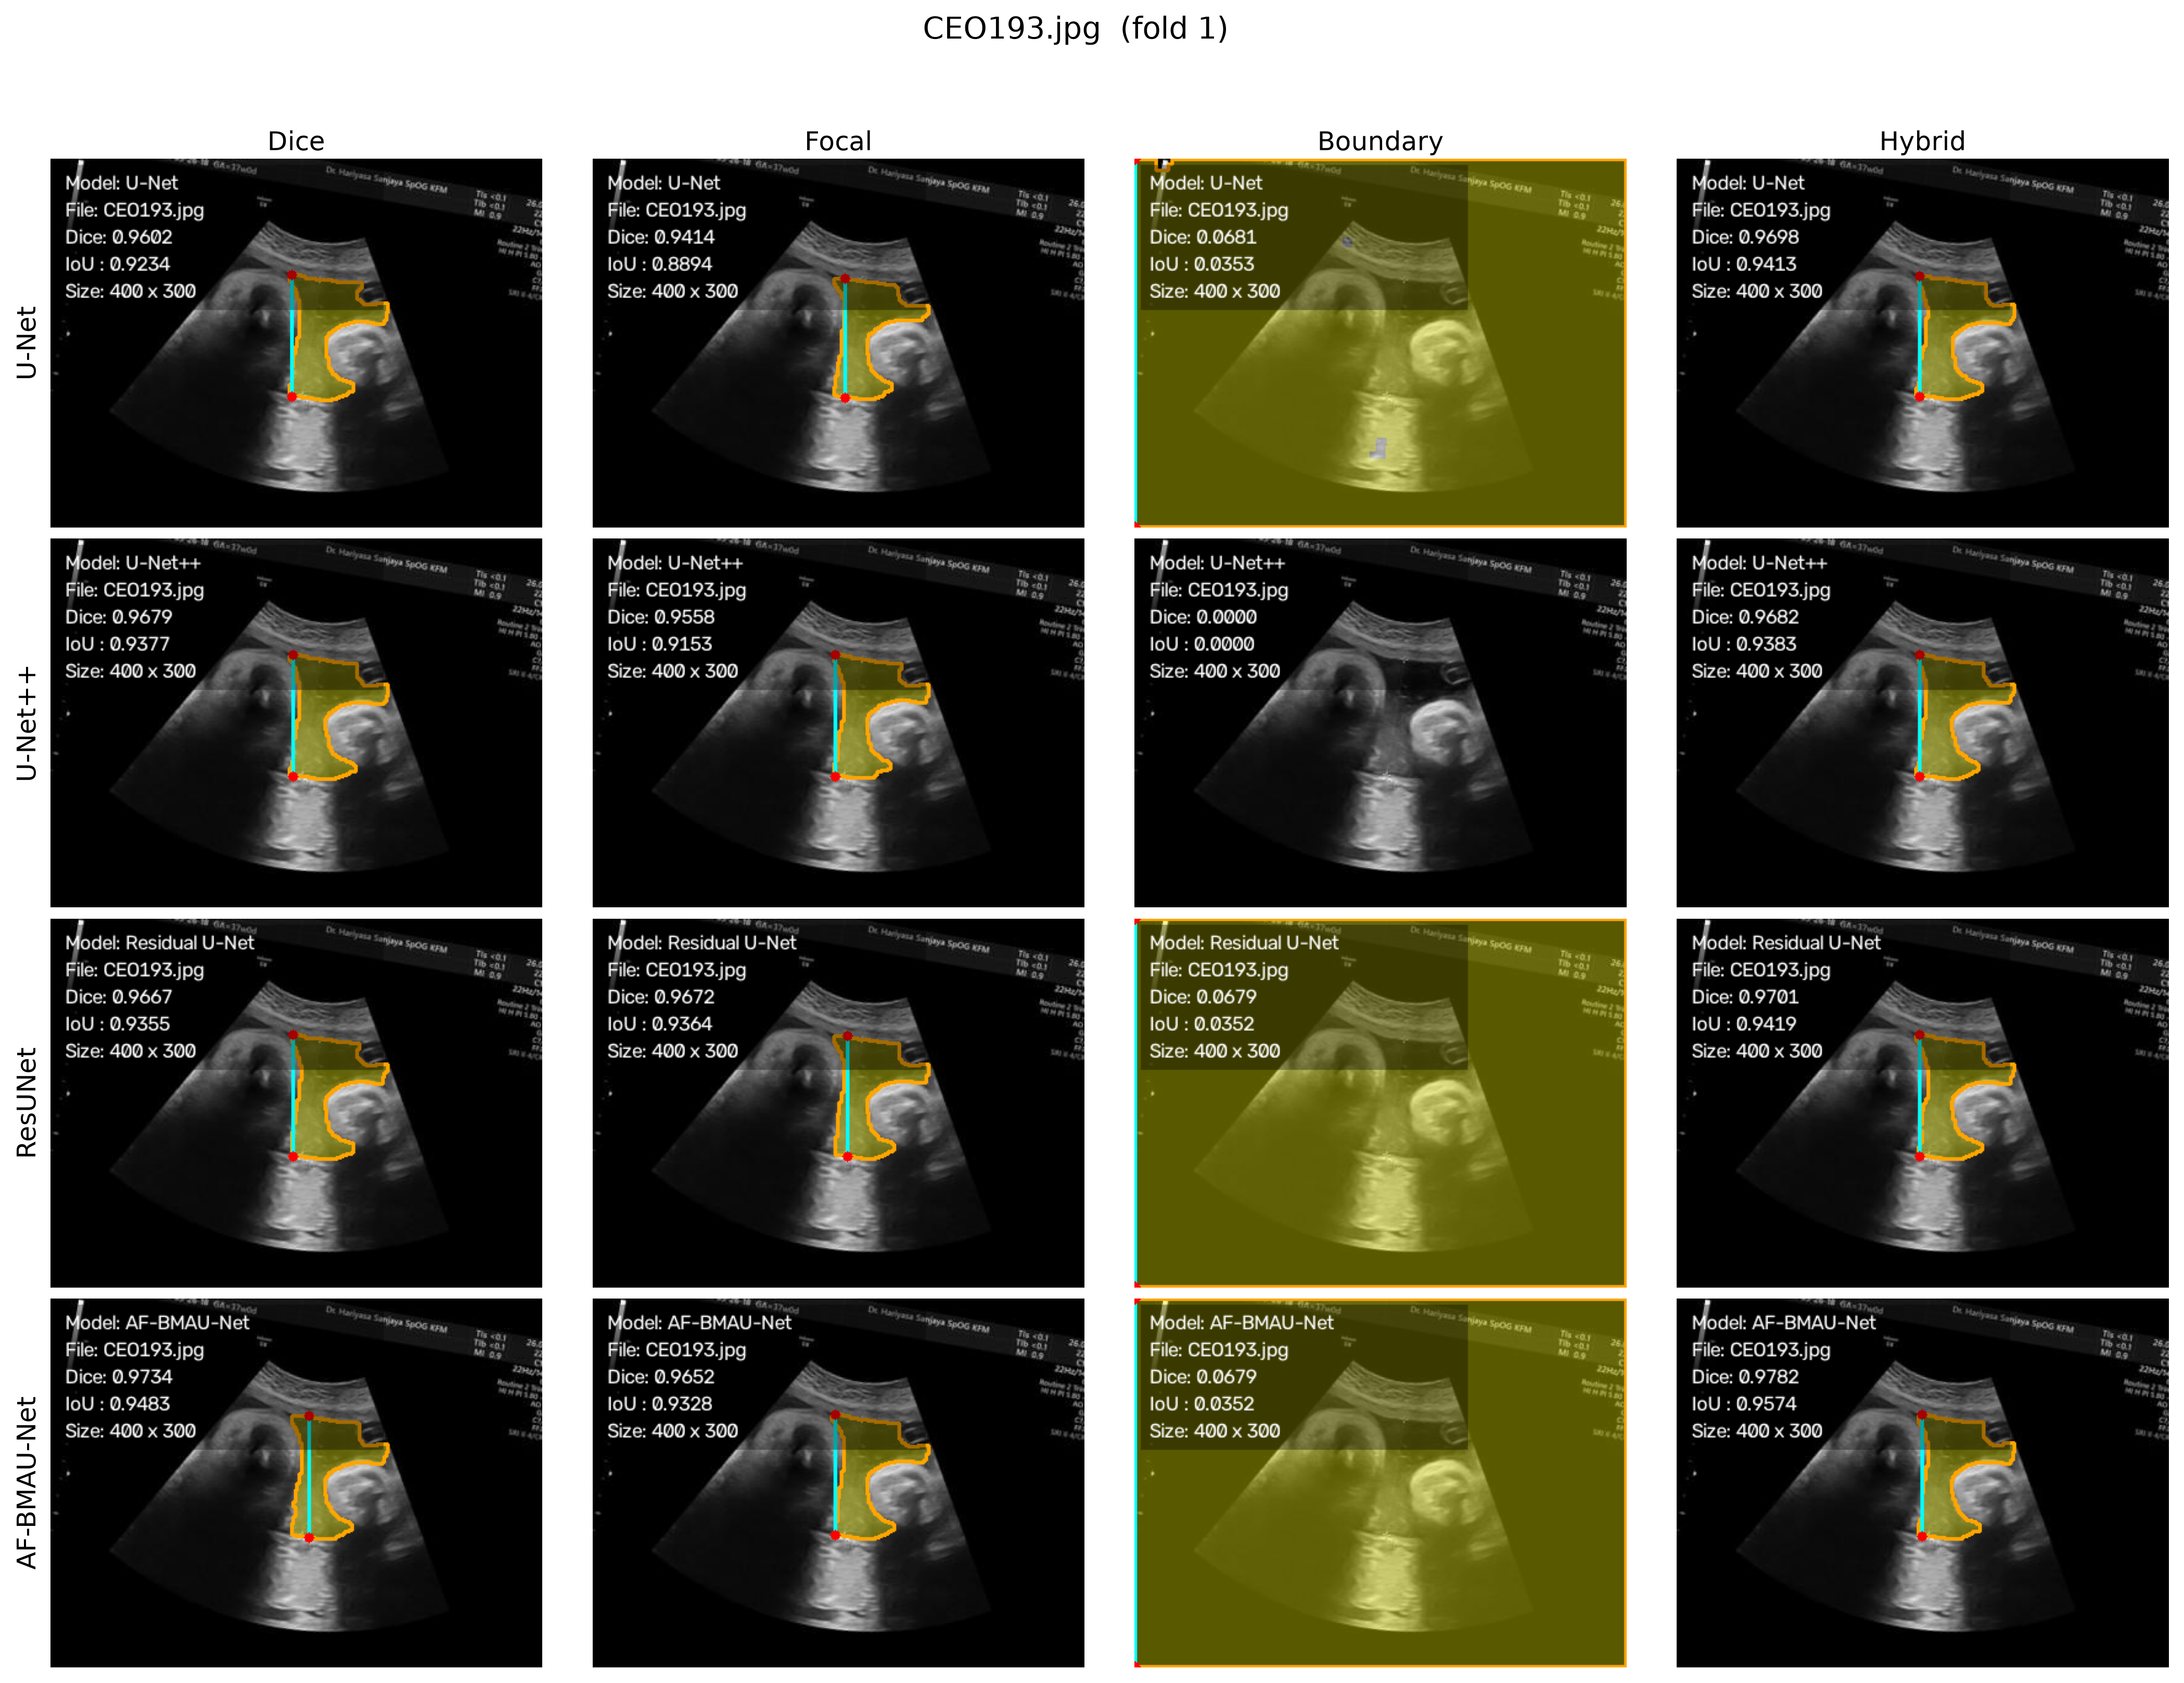

Saved hi-res figure to d:\ITB STIKOM BALI\PENELITIAN\PENELITIAN DIKTI\DRTPM 2026\dikti-2026-angga-segmentation\outputs\figures\comparison_CEO193.png


In [11]:
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
comparison_plot(cherry_picked, save_path=FIG_DIR / f"comparison_{Path(cherry_picked).stem}.png")
plt.show()
print(f"Saved hi-res figure to {FIG_DIR / f'comparison_{Path(cherry_picked).stem}.png'}")